In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load labeled data
iris = load_iris()
X, y = iris.data, iris.target

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model (supervised: we provide both X AND y)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)  # Learn from labeled data

# Predict on new data
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")  # ~96.67%

Accuracy: 100.00%


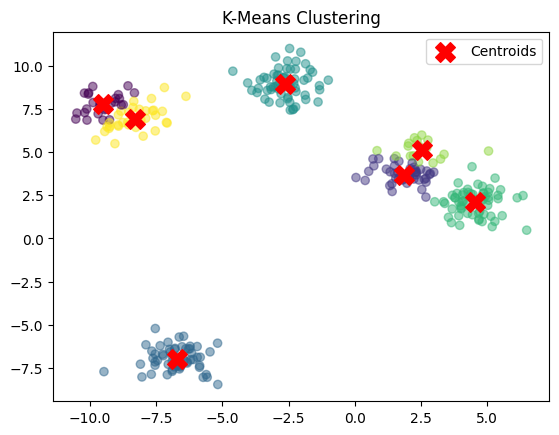

In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate unlabeled data (3 clusters)
X, _ = make_blobs(n_samples=300, centers=5, cluster_std=0.8, random_state=42)

# Unsupervised: we only give X, no labels!
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
predictions = kmeans.fit_predict(X)

# Visualization
plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap='viridis', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering')
plt.legend()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generate linear data with noise: y = 4 + 3x
np.random.seed(42)
X = 2 * np.random.rand(100)
y = 4 + 3 * X + np.random.randn(100) * 0.5  

# Gradient Descent from Scratch
w, b = 0.0, 0.0  # Initialize weights
lr = 0.1         # Learning rate
n = len(X)
losses = []

for epoch in range(100):
    y_pred = w * X + b
    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)
    
    # Compute gradients (derivatives of MSE)
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    # Update weights
    w -= lr * dw
    b -= lr * db

print(f"Learned: y = {w:.2f}x + {b:.2f}")
print(f"True:    y = 3.00x + 4.00")

Learned: y = 2.91x + 4.08
True:    y = 3.00x + 4.00


Dataset shape: (569, 30)

Accuracy: 95.61%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



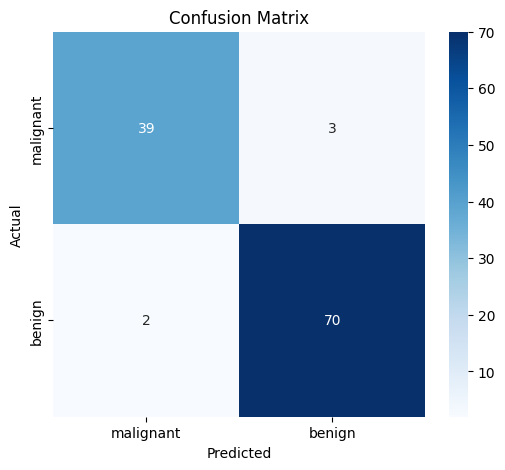

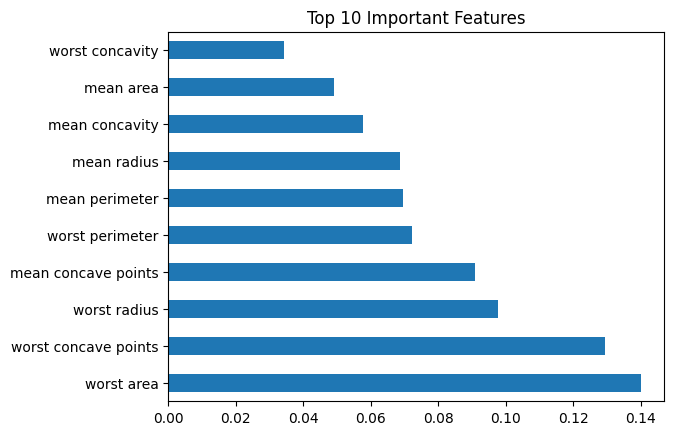

In [4]:
# ============================================================
# COMPLETE ML PIPELINE: Breast Cancer Classification
# ============================================================

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print(f"Dataset shape: {X.shape}")

# 2. Split Data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Preprocess (Scale features to have mean=0, variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Evaluate
y_pred = model.predict(X_test_scaled)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 6. Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 7. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', title='Top 10 Important Features')
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a sample dataset for demonstration
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'age': np.random.normal(35, 12, n).clip(18, 80),
    'income': np.random.lognormal(10.5, 0.8, n),
    'education': np.random.choice(['High School', 'Bachelors', 'Masters', 'PhD'], n, p=[0.4, 0.4, 0.15, 0.05]),
    'credit_score': np.random.normal(650, 80, n).clip(300, 850),
    'churned': np.random.binomial(1, 0.2, n)
})
# Inject some missing values
df.loc[np.random.choice(n, 50), 'income'] = np.nan

# ==========================================
# 1. Basic Structure
# ==========================================
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")

# ==========================================
# 2. Missing Values Analysis
# ==========================================
missing = df.isnull().sum()
print(f"\nMissing Values:\n{missing[missing > 0]}")

# ==========================================
# 3. Numerical Summary
# ==========================================
print(f"\nNumerical Summary:\n{df.describe().round(2)}")

# ==========================================
# 4. Target Variable Analysis
# ==========================================
churn_rate = df['churned'].mean()
print(f"\nOverall Churn Rate: {churn_rate:.2%}")
print(df['churned'].value_counts())

Shape: (1000, 5)

Data Types:
age             float64
income          float64
education        object
credit_score    float64
churned           int32
dtype: object

Missing Values:
income    50
dtype: int64

Numerical Summary:
           age     income  credit_score  churned
count  1000.00     950.00       1000.00   1000.0
mean     35.55   52399.32        649.28      0.2
std      11.14   47413.61         82.29      0.4
min      18.00    3455.38        410.71      0.0
25%      27.23   22369.37        592.55      0.0
50%      35.30   38195.09        649.89      0.0
75%      42.78   64964.57        704.87      0.0
max      80.00  467187.55        850.00      1.0

Overall Churn Rate: 20.20%
churned
0    798
1    202
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18380\654893678.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education', ax=axes[2], palette='viridis',


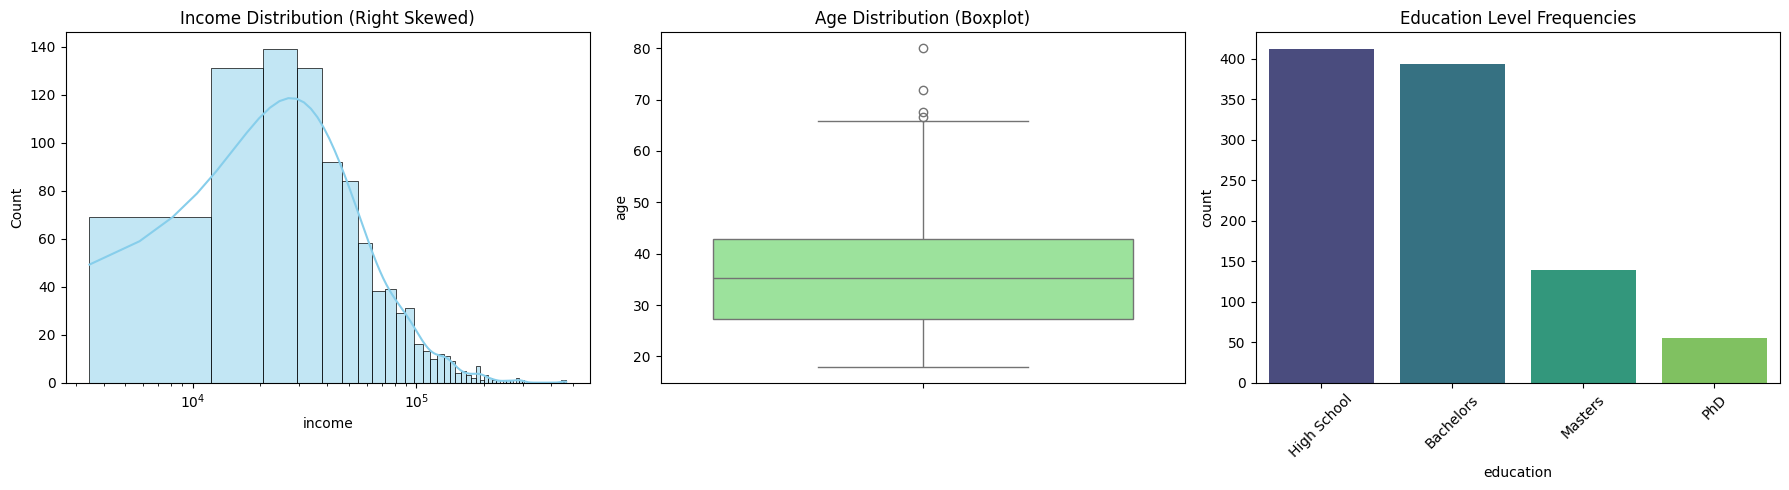

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram + KDE for Income (Numerical)
sns.histplot(df['income'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Income Distribution (Right Skewed)')
axes[0].set_xscale('log') # Log scale because income is highly skewed

# 2. Boxplot for Age (Numerical)
sns.boxplot(y=df['age'], ax=axes[1], color='lightgreen')
axes[1].set_title('Age Distribution (Boxplot)')

# 3. Countplot for Education (Categorical)
sns.countplot(data=df, x='education', ax=axes[2], palette='viridis', 
              order=['High School', 'Bachelors', 'Masters', 'PhD'])
axes[2].set_title('Education Level Frequencies')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18380\622095441.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='education', y='credit_score', ax=axes[1], palette='Set2',


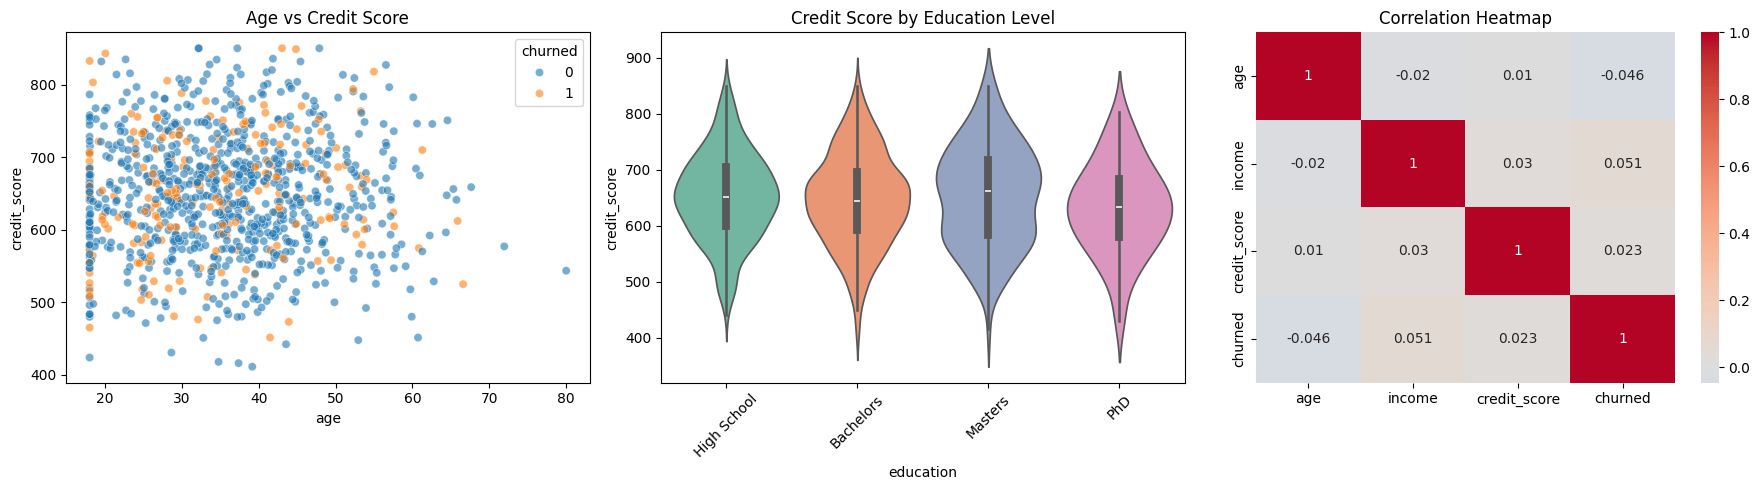

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatterplot: Age vs Credit Score (colored by Churn)
sns.scatterplot(data=df, x='age', y='credit_score', hue='churned', alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Credit Score')

# 2. Violinplot: Credit Score by Education
sns.violinplot(data=df, x='education', y='credit_score', ax=axes[1], palette='Set2',
               order=['High School', 'Bachelors', 'Masters', 'PhD'])
axes[1].set_title('Credit Score by Education Level')
axes[1].tick_params(axis='x', rotation=45)

# 3. Correlation Heatmap
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

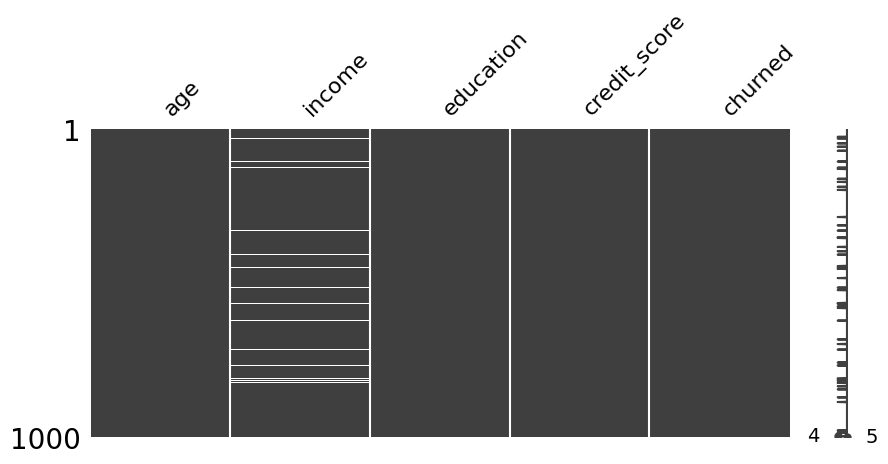

In [8]:
import missingno as msno

# Visualizes where missing values occur in the dataset
msno.matrix(df, figsize=(10, 4))
plt.show()

In [9]:
# IQR Method for Outlier Detection
Q1 = df['credit_score'].quantile(0.25)
Q3 = df['credit_score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['credit_score'] < lower_bound) | (df['credit_score'] > upper_bound)]
print(f"Detected {len(outliers)} outliers in Credit Score.")

Detected 4 outliers in Credit Score.


In [10]:
# Example using ydata-profiling
# pip install ydata-profiling

from ydata_profiling import ProfileReport

# Generate the report with explorative mode (calculates more interactions)
profile = ProfileReport(df, title="Customer Dataset Profiling Report", explorative=True)


# Save to HTML
profile.to_file("report.html")

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18380\3843341725.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
Summarize dataset:  58%|█████▊    | 7/12 [00:00<00:00,  9.35it/s, Calculate auto correlation]C:\Users\ADMIN\AppData\Roaming\Python\Python310\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 9 9 9 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 9 9 0 0 0 0 

In [12]:
from scipy import stats

income_skew = df['income'].dropna().skew()
income_kurt = df['income'].dropna().kurtosis()

print(f"Income Skewness: {income_skew:.2f} (Highly right-skewed)")
print(f"Income Kurtosis: {income_kurt:.2f} (Heavy tails)")

Income Skewness: 2.94 (Highly right-skewed)
Income Kurtosis: 14.74 (Heavy tails)


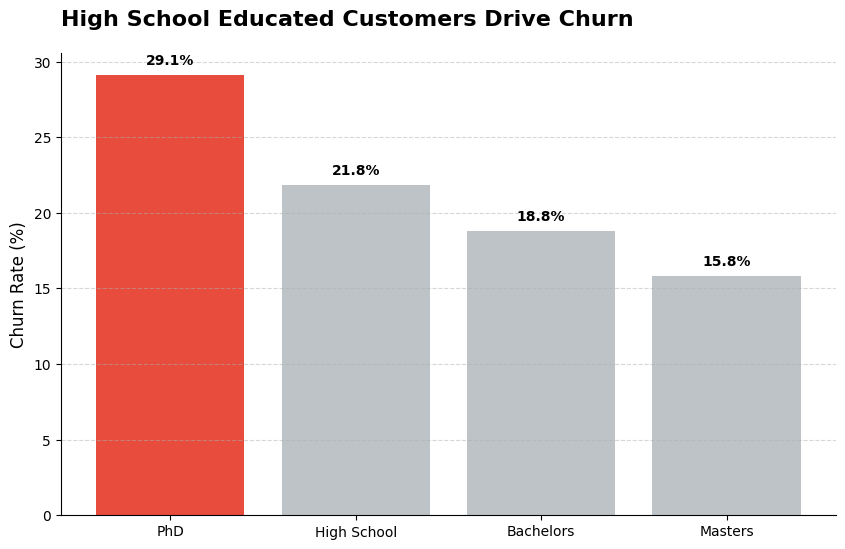

In [13]:
# A presentation-ready chart
plt.figure(figsize=(10, 6))

# Group data for visualization
churn_by_edu = df.groupby('education')['churned'].mean().sort_values(ascending=False) * 100

bars = plt.bar(churn_by_edu.index, churn_by_edu.values, color=['#e74c3c', '#bdc3c7', '#bdc3c7', '#bdc3c7'])

# Annotations
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", 
             ha='center', va='bottom', fontweight='bold')

# Styling for presentation
plt.title('High School Educated Customers Drive Churn', fontsize=16, fontweight='bold', pad=20, loc='left')
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()